In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
# data = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
df = pd.read_csv('../datasets/data_lr_assumptions.csv')

In [3]:
# Display the first few rows of the dataset
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [4]:
X = df.iloc[:, 0:3].values
y = df.iloc[:, -1].values

In [5]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Train a linear regression model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

In [7]:
# Calculate residuals
residuals = y_test - y_pred

    1. Linear Relationship

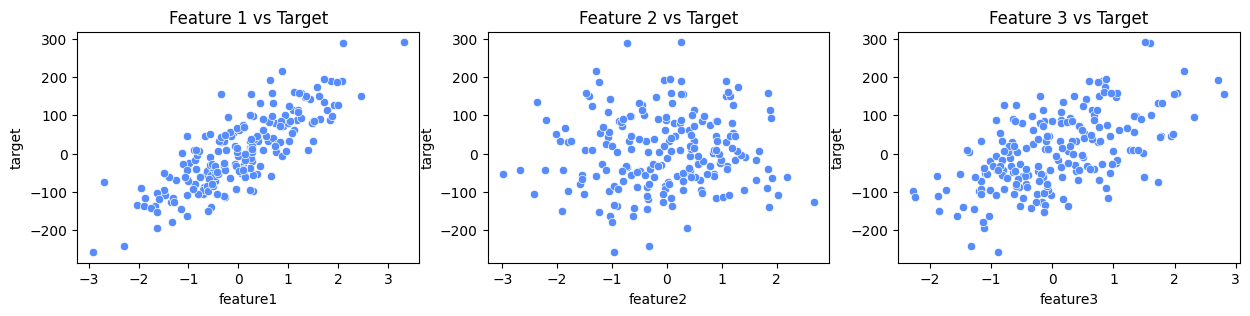

In [8]:
#   1. Linear Relationship
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(15, 3))
sns.scatterplot(x=df.iloc[:, 0], y=df.iloc[:, -1], ax=ax1)
sns.scatterplot(x=df.iloc[:, 1], y=df.iloc[:, -1], ax=ax2)
sns.scatterplot(x=df.iloc[:, 2], y=df.iloc[:, -1], ax=ax3)
ax1.set_title('Feature 1 vs Target')
ax2.set_title('Feature 2 vs Target')
ax3.set_title('Feature 3 vs Target')
plt.show()

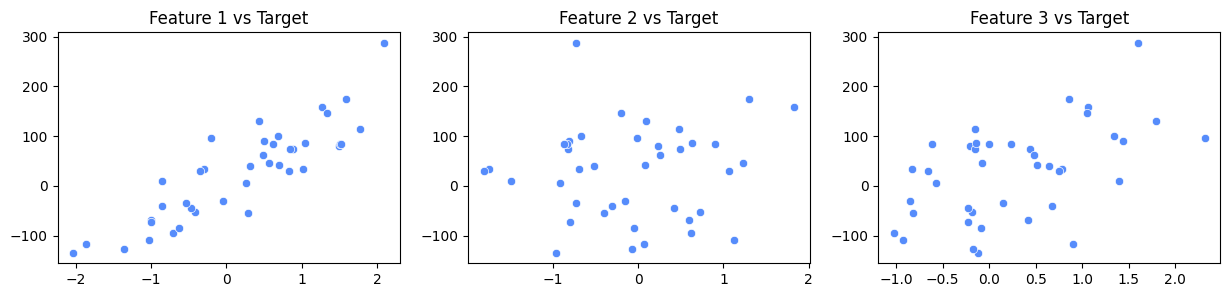

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(15, 3))
sns.scatterplot(x=X_test[:, 0], y=y_test, ax=ax1)
sns.scatterplot(x=X_test[:, 1], y=y_test, ax=ax2)
sns.scatterplot(x=X_test[:, 2], y=y_test, ax=ax3)
ax1.set_title('Feature 1 vs Target')
ax2.set_title('Feature 2 vs Target')
ax3.set_title('Feature 3 vs Target')
plt.show()

2. Multicollinearity

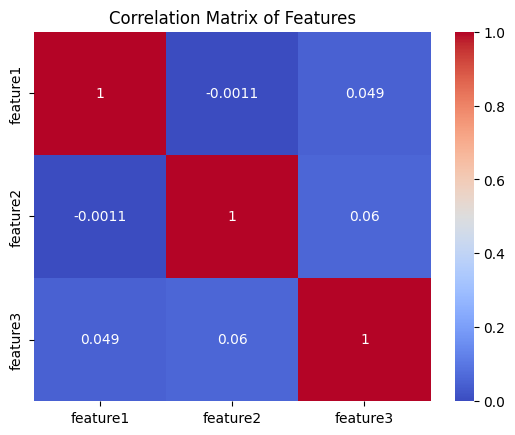

In [10]:
#   2. No Multicollinearity
sns.heatmap(df.iloc[:, 0:3].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['feature'] = df.columns[0:3]
vif_data['VIF'] = [variance_inflation_factor(df.iloc[:, 0:3].values, i) for i in range(df.iloc[:, 0:3].shape[1])]
print(vif_data)

    feature       VIF
0  feature1  1.002545
1  feature2  1.003410
2  feature3  1.005937


3. Normality of Residual

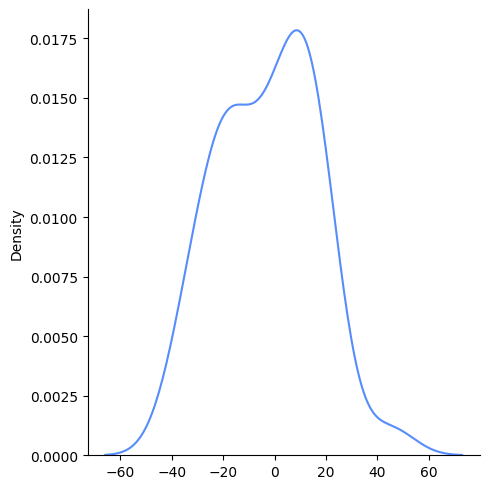

In [12]:
# 3. Normality of Errors
sns.displot(residuals,kind='kde')

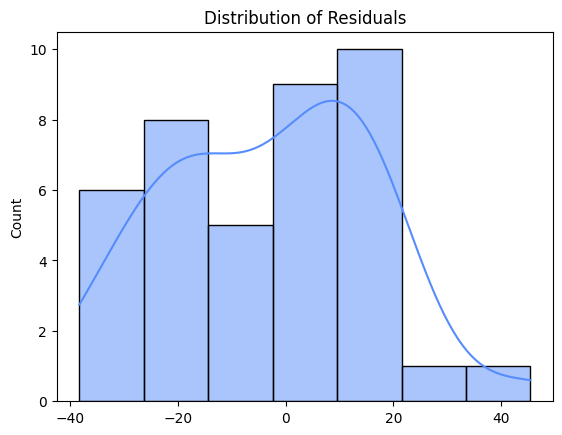

In [13]:
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.show()

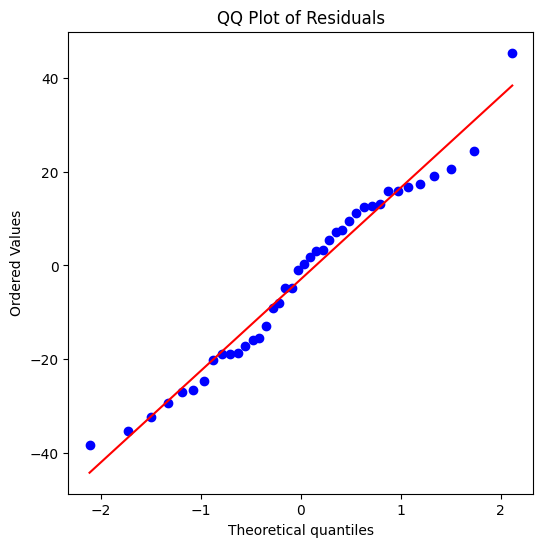

In [14]:
# QQ Plot
import scipy.stats as stats
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ Plot of Residuals')
plt.show()

4. Homoscedasticity

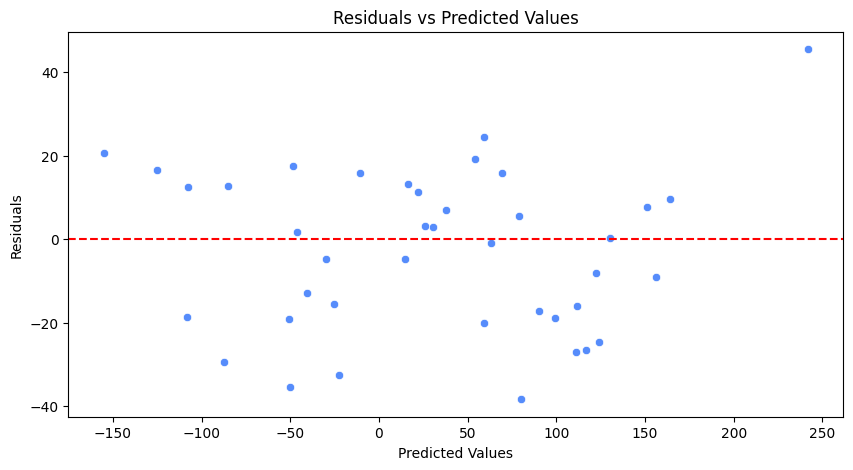

In [15]:
#   4. Homoscedasticity
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

5. Autocorrelation of Residuals

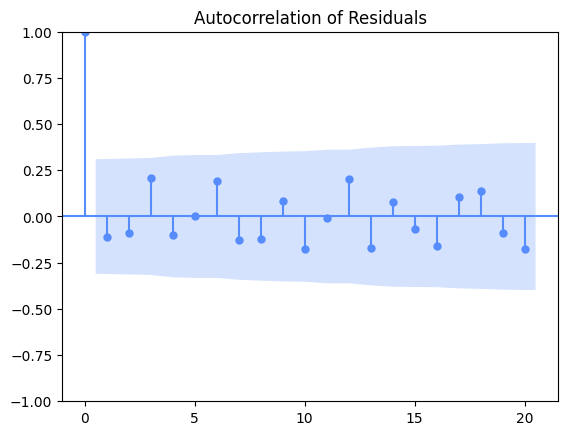

In [16]:
# 5. Autocorrelation of Residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=20)
plt.title('Autocorrelation of Residuals')
plt.show()

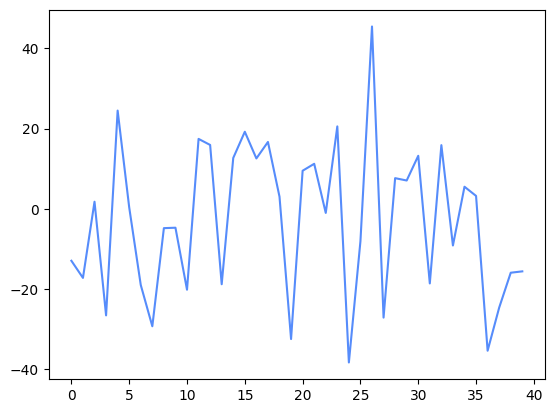

In [17]:
plt.plot(residuals)

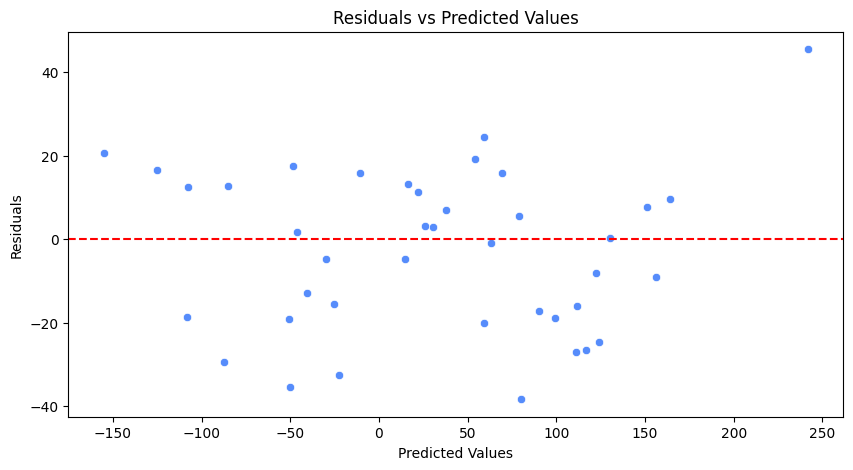

In [18]:
# 6. Independence of Errors
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

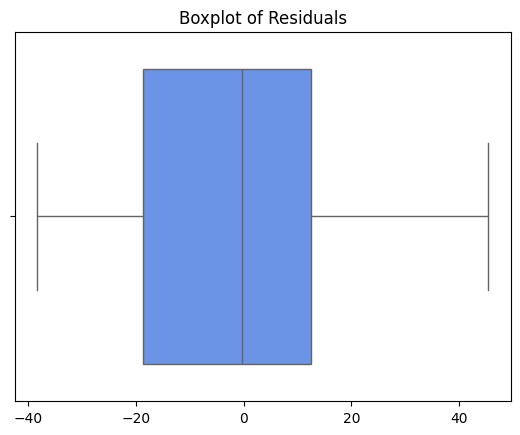

In [19]:
sns.boxplot(x=residuals)
plt.title('Boxplot of Residuals')
plt.show()